# NumPy Project 2 — Matrix Operations and Antenna Arrays

## What this project does
Practises NumPy matrix operations and connects them directly to
antenna array theory — steering vectors, array responses, and
basic beamforming.

## NumPy concepts covered
- 2D arrays and matrix operations
- np.dot(), np.matmul(), @  operator
- np.linalg functions
- Complex numbers in NumPy
- Broadcasting

## RF concept introduced
- Uniform Linear Array (ULA)
- Steering vectors
- Array factor and beam pattern

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- 2D arrays ---
A = np.array([[1, 2, 3],[4, 5, 6],[7, 8, 9]])
# np.array() with nested lists creates a 2D array (matrix)
# shape is (3, 3) — 3 rows, 3 columns

B = np.array([[9, 8, 7],[6, 5, 4],[3, 2, 1]])
print(f"A shape: {A.shape}")
# .shape: tuple (rows, cols)

print(f"A + B:\n{A + B}")
# element-wise addition — adds corresponding elements

print(f"A * B:\n{A * B}")
# element-wise multiplication — NOT matrix multiplication

print(f"A @ B:\n{A @ B}")
# @ operator: TRUE matrix multiplication (dot product of rows and columns)
# this is what you use for signal processing and beamforming calculations

print(f"A.T:\n{A.T}")
# .T: transpose — flips rows and columns
# rows become columns, columns become rows

A shape: (3, 3)
A + B:
[[10 10 10]
 [10 10 10]
 [10 10 10]]
A * B:
[[ 9 16 21]
 [24 25 24]
 [21 16  9]]
A @ B:
[[ 30  24  18]
 [ 84  69  54]
 [138 114  90]]
A.T:
[[1 4 7]
 [2 5 8]
 [3 6 9]]


In [7]:
# complex numbers are essential in RF — signals have magnitude AND phase
# in Python/NumPy: j is the imaginary unit (not i like in maths)

z1 = 3+4j
# complex number: real part=3, imaginary part=4
# represents a signal with magnitude and phase

z2 = np.array([1+2j, 3+4j, 5+6j])

print(f"z1 = {z1}")
print(f"Magnitude of z1: {np.abs(z1):.4f}")
# np.abs() on complex number: computes magnitude = sqrt(real² + imag²)
# |3 + 4j| = sqrt(9 + 16) = sqrt(25) = 5

print(f"Phase of z1: {np.angle(z1) * 180/np.pi:.4f} degrees")
# np.angle(): returns phase angle in radians
# * 180/np.pi: converts radians to degrees

print(f"Real part: {z1.real}")
# .real: extracts the real part of a complex number

print(f"Imaginary part: {z1.imag}")
# .imag: extracts the imaginary part

print(f"\nComplex array magnitudes: {np.abs(z2).round(4)}")
print(f"Complex array phases (deg): {(np.angle(z2)*180/np.pi).round(4)}")

# complex exponential — the most important formula in RF
theta = np.pi / 4    # phase angle of 45 degrees in radians
e = np.exp(1j * theta)
# np.exp(1j * theta): Euler's formula — e^(jθ) = cos(θ) + j*sin(θ)
# this represents a pure phase shift of theta radians
# used everywhere: FFT, modulation, steering vectors, channel models

print(f"\ne^(j*π/4) = {e:.4f}")
print(f"Magnitude: {np.abs(e):.4f}  (always 1 for pure phase shift)")
print(f"Phase: {np.angle(e)*180/np.pi:.4f} degrees  (should be 45°)")

z1 = (3+4j)
Magnitude of z1: 5.0000
Phase of z1: 53.1301 degrees
Real part: 3.0
Imaginary part: 4.0

Complex array magnitudes: [2.2361 5.     7.8102]
Complex array phases (deg): [63.4349 53.1301 50.1944]

e^(j*π/4) = 0.7071+0.7071j
Magnitude: 1.0000  (always 1 for pure phase shift)
Phase: 45.0000 degrees  (should be 45°)


In [64]:
# --- Uniform Linear Array (ULA) steering vector ---
# a ULA is a row of antennas equally spaced
# when a signal arrives at an angle, it hits each antenna at a slightly different time
# this time difference creates a phase shift between antennas
# the steering vector captures these phase shifts mathematically

N = 8              # number of antennas in the array
d = 0.5            # antenna spacing in wavelengths (0.5λ is standard)
theta = 30         # angle of arrival in degrees

theta_rad = np.deg2rad(theta)
# np.deg2rad(): converts degrees to radians
# NumPy trig functions always work in radians

# compute phase shift between adjacent antennas
phase_shift = 2 * np.pi * d * np.sin(theta_rad)
# 2 * np.pi: one full cycle in radians
# d * np.sin(theta_rad): path length difference between adjacent antennas
# in wavelengths — how much extra distance the signal travels to each antenna

# build the steering vector
n = np.arange(N)
# n = [0, 1, 2, 3, 4, 5, 6, 7] — antenna indices

steering_vector = np.exp(1j*phase_shift*n)
# np.exp(1j * phase_shift * n): phase shift for each antenna
# antenna 0: e^(j*0) = 1 (reference, no shift)
# antenna 1: e^(j*phase_shift)
# antenna 2: e^(j*2*phase_shift)
# each antenna has one more phase step than the previous
# result: complex array of length N

print(f"Number of antennas: {N}")
print(f"Antenna spacing: {d} wavelengths")
print(f"Angle of arrival: {theta} degrees")
print(f"Phase shift between antennas: {np.rad2deg(phase_shift):.2f} degrees")
print(f"\nSteering vector magnitudes: {np.abs(steering_vector).round(4)}")
# all magnitudes should be 1.0 — pure phase shifts
print(f"Steering vector phases (deg): {(np.angle(steering_vector)*180/np.pi).round(2)}")


Number of antennas: 8
Antenna spacing: 0.5 wavelengths
Angle of arrival: 30 degrees
Phase shift between antennas: 90.00 degrees

Steering vector magnitudes: [1. 1. 1. 1. 1. 1. 1. 1.]
Steering vector phases (deg): [  0.  90. 180. -90.  -0.  90. 180. -90.]


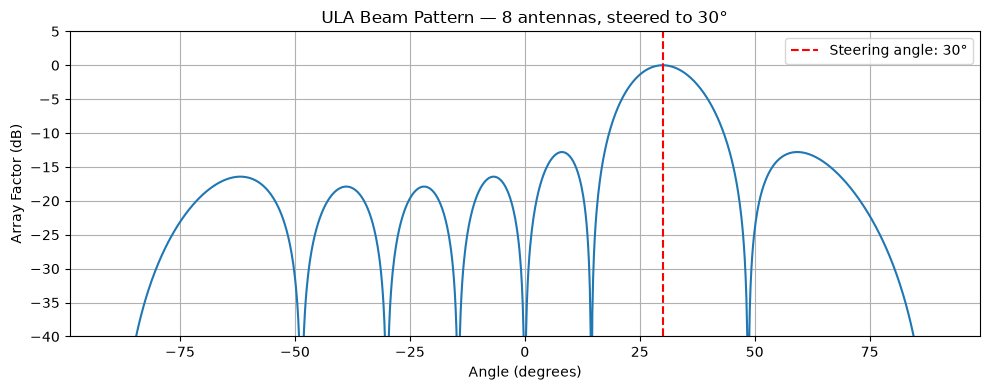

In [65]:
# --- compute beam pattern across all angles ---
# the beam pattern shows how strongly the array responds
# to signals arriving from different directions

angles = np.linspace(-90, 90, 1000)
# np.linspace(-90, 90, 1000): 1000 angles from -90° to +90°
# these are all possible directions a signal could arrive from

radians =np.deg2rad(angles)
# convert all angles to radians at once — NumPy applies to whole array

steering_rad = np.deg2rad(theta)

# compute array factor for each angle
af = np.zeros(len(angles), dtype=complex)
# np.zeros(): initialise output array with zeros
# dtype=complex: must be complex because steering vectors are complex

for i, rad in enumerate(radians):
    # enumerate(): gives index i and value angle_rad together
    sv_steer = np.exp(1j * 2 * np.pi * d * np.sin(rad) * n)
    # steering vector for this angle

    sv_signal = np.exp(-1j * 2 * np.pi * d * np.sin(steering_rad) * n)
    # compensation vector for our chosen steering direction
    # negative sign: this SUBTRACTS the steering phase from each antenna
    # it is fixed — same for every angle since we always steer to theta
    # this is what actually points the beam toward theta

    af[i] = np.sum(sv_steer * sv_signal)
    # multiply element-wise then sum
    # when angle_rad == theta_rad: sv_signal * sv_steer = e^(j*x) * e^(-j*x) = 1
    # all ones sum to N = maximum output
    # when angle_rad != theta_rad: phases don't cancel, sum is smaller

# normalise so maximum is 1.0
af_magnitude = np.abs(af)
af_normalised = af_magnitude / np.max(af_magnitude)
# / np.max(): divides every value by the maximum
# result: values between 0 and 1

# convert to dB for plotting
af_db = 20 * np.log10(af_normalised + 1e-10)
# 20 * np.log10(): converts magnitude to dB
# + 1e-10: tiny offset to avoid log(0) which is undefined

plt.figure(figsize=(10, 4))
plt.plot(angles, af_db)
plt.axvline(x=theta, color='r', linestyle='--',
            label=f"Steering angle: {theta}°")
# axvline(): vertical red line showing where we steered the beam

plt.xlabel("Angle (degrees)")
plt.ylabel("Array Factor (dB)")
plt.title(f"ULA Beam Pattern — {N} antennas, steered to {theta}°")
plt.ylim(-40, 5)
# plt.ylim(): set y axis limits — cut off very deep nulls for clean plot
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

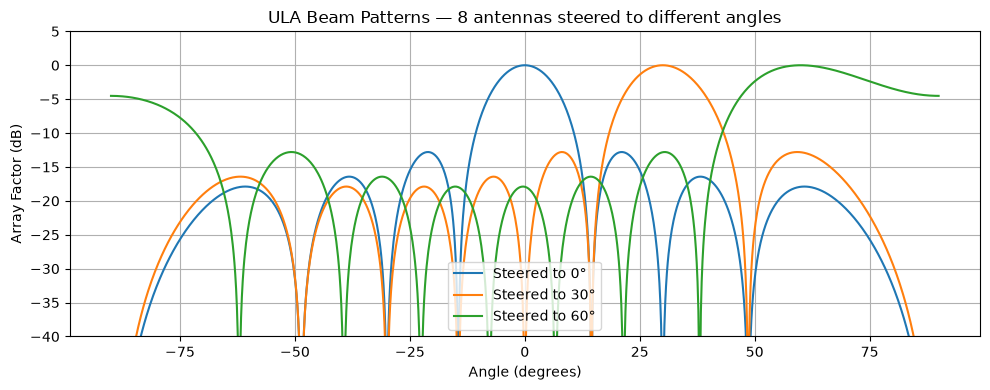

In [66]:
# --- compare beam patterns at different steering angles ---
steering_angles = [0, 30, 60]
# three different directions to steer the beam

plt.figure(figsize=(10, 4))

for steer in steering_angles:
    steer_rad = np.deg2rad(steer)
    array_factor = np.zeros(len(angles), dtype= complex)

    for i, angle_rad in enumerate(radians):
        sv_steering = np.exp(1j * 2 * np.pi * d * np.sin(angle_rad) * n)
        # steering vector for incoming signal direction
        
        sv_fixed = np.exp(-1j * 2 * np.pi * d * np.sin(steer_rad) * n)
         # np.exp(-1j * ...): conjugate steering vector
         # negative sign: this is the compensation phase we apply
         # to align all antenna signals before summing

        array_factor[i] = np.sum(sv_steering * sv_fixed)
        # element-wise multiply then sum — this is beamforming
        # when signal angle matches steering angle: phases cancel → maximum output
        # when they differ: phases don't cancel → reduced output

    array_factor_mag = np.abs(array_factor)
    array_factor_max = np.max(array_factor_mag)
    array_factor_normalized = np.abs(array_factor) / np.max(array_factor_mag)

    afactor_db = 20 * np.log10(array_factor_normalized + 1e-10)
    plt.plot(angles, afactor_db, label=f"Steered to {steer}°")

plt.xlabel("Angle (degrees)")
plt.ylabel("Array Factor (dB)")
plt.title(f"ULA Beam Patterns — {N} antennas steered to different angles")
plt.ylim(-40, 5)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [58]:
# --- linear algebra operations used in signal processing ---
# these are used in MMSE channel estimation and MVDR beamforming

M = np.array([[4, 2],
              [1, 3]], dtype=float)
# simple 2x2 matrix for demonstration

det = np.linalg.det(M)
# np.linalg.det(): determinant of matrix
# non-zero determinant means matrix is invertible

inv_M = np.linalg.inv(M)
# np.linalg.inv(): matrix inverse
# used in MMSE estimator: W = (H^H * H + σ²I)^(-1) * H^H

eigenvalues, eigenvectors = np.linalg.eig(M)
# np.linalg.eig(): eigenvalue decomposition
# eigenvalues: how much each eigenvector is scaled
# eigenvectors: principal directions of the matrix
# used in MIMO channel capacity calculations

print(f"Matrix M:\n{M}")
print(f"\nDeterminant: {det:.4f}")
print(f"\nInverse:\n{inv_M.round(4)}")
print(f"\nEigenvalues: {eigenvalues.round(4)}")
print(f"\nVerify M @ inv(M) = I:\n{(M @ inv_M).round(4)}")
# M @ inv_M should give identity matrix (1s on diagonal, 0s elsewhere)

Matrix M:
[[4. 2.]
 [1. 3.]]

Determinant: 10.0000

Inverse:
[[ 0.3 -0.2]
 [-0.1  0.4]]

Eigenvalues: [5. 2.]

Verify M @ inv(M) = I:
[[ 1.  0.]
 [-0.  1.]]


## Key observations
- Beam pattern is maximum at steering angle due to constructive interference
- Compensation vector controls the beam and so it acheives maximum at the steering angle
- Steering vector magnitude is 1

## What I learned
- @ operator is matrix multiplication, * is element-wise
- Complex exponentials represent phase shifts — magnitude always 1
- Steering vector captures the phase difference between antennas
- Beamforming works by aligning phases so signals add up in one direction
- np.linalg provides matrix inverse and eigenvalues used in advanced algorithms